# load data

In [74]:
# Imports
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [75]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mostafa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Mostafa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [76]:
df = pd.read_csv("Reviews.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


# Cleaning & EDA

In [77]:
df.shape

(568454, 10)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [79]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [80]:
df = df.dropna()

In [81]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [82]:
df.duplicated().sum()

0

In [83]:
df["Score"].value_counts()

Score
5    363102
4     80654
1     52264
3     42638
2     29743
Name: count, dtype: int64

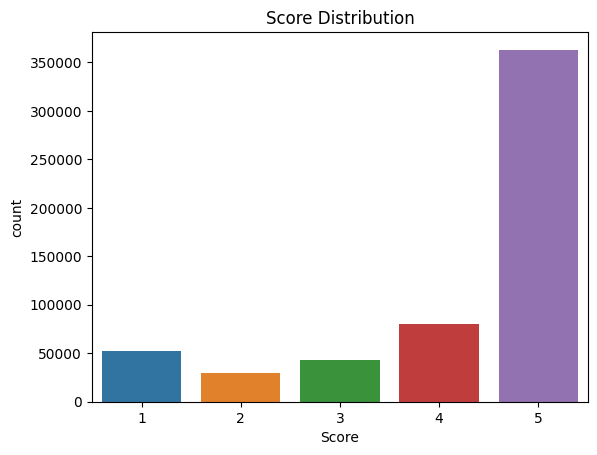

In [84]:
sns.countplot(x=df["Score"],data=df)
plt.title("Score Distribution")
plt.show()

In [85]:
df = df[df['Score'] != 3].copy()
df['Sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

df['Sentiment'].value_counts()

Sentiment
1    443756
0     82007
Name: count, dtype: int64

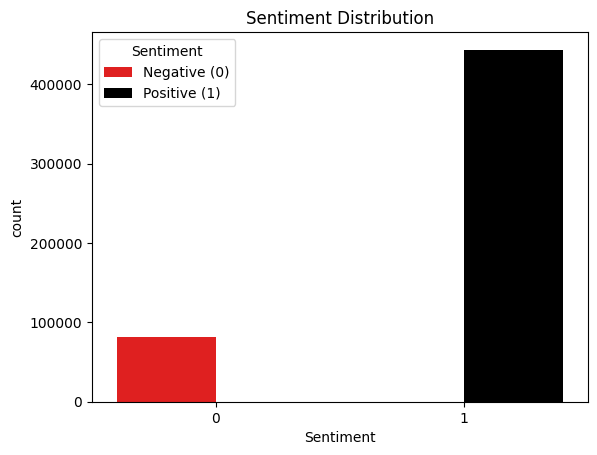

In [ ]:
sns.countplot(x ="Sentiment",data=df,hue="Sentiment",palette=["red","black"])
plt.title("Sentiment Distribution")
plt.legend(title="Sentiment", labels=["Negative (0)", "Positive (1)"])
plt.show()
# We can see from figure that there is inbalance between positive and negative.

In [87]:
df = df[["Sentiment","Text"]].copy()
df.head()

,Sentiment,Text
0,1,I have bought several of the Vitality canned d...
1,0,Product arrived labeled as Jumbo Salted Peanut...
2,1,This is a confection that has been around a fe...
3,0,If you are looking for the secret ingredient i...
4,1,Great taffy at a great price. There was a wid...


In [88]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_text"] = df["Text"].apply(clean_text)

In [89]:
df.head()

,Sentiment,Text,clean_text
0,1,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...
1,0,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...
2,1,This is a confection that has been around a fe...,confection around centuries light pillowy citr...
3,0,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...
4,1,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...


# Preprocessing

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["Sentiment"],
    test_size=0.2,
    random_state=42
)

In [92]:
tfidf = TfidfVectorizer(max_features=8000)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

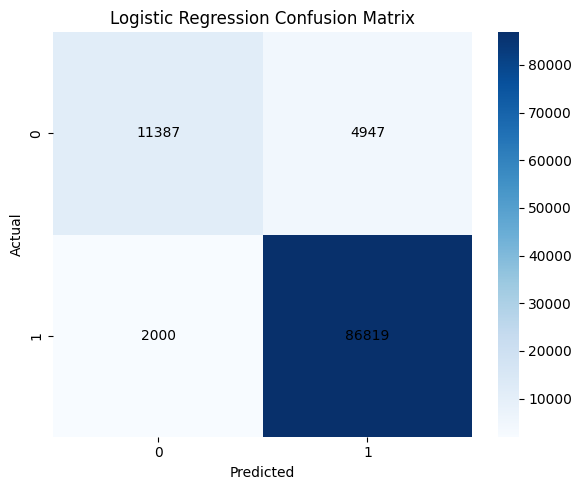


===== Logistic Regression =====
Accuracy: 0.9339343623101576
              precision    recall  f1-score   support

           0       0.85      0.70      0.77     16334
           1       0.95      0.98      0.96     88819

    accuracy                           0.93    105153
   macro avg       0.90      0.84      0.86    105153
weighted avg       0.93      0.93      0.93    105153



In [122]:
# As we know there is inbalance between Sentiment. 
# We will use class_weight='balanced' to make the model gives the greater weight to the lower category (negative).
# If model has low accuarcy although using class_weight='balanced' we will use SMOTE to deal with inbalance in data.

lr_model = LogisticRegression()
lr_model.fit(X_train_vec, y_train)

lr_pred = lr_model.predict(X_test_vec)
lr_acc = accuracy_score(y_test, lr_pred)

cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6,5))
ax = sns.heatmap(cm, cmap="Blues", cbar=True)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.5, cm[i, j],
                ha='center', va='center')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\n===== Logistic Regression =====")
print("Accuracy:", lr_acc)
print(classification_report(y_test, lr_pred))


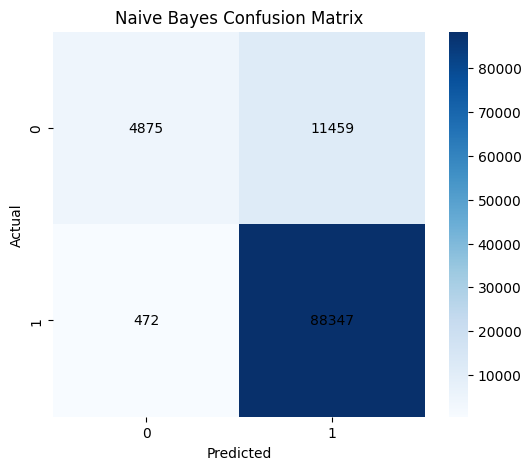


===== Naive Bayes =====
Accuracy: 0.8865367607200936
              precision    recall  f1-score   support

           0       0.91      0.30      0.45     16334
           1       0.89      0.99      0.94     88819

    accuracy                           0.89    105153
   macro avg       0.90      0.65      0.69    105153
weighted avg       0.89      0.89      0.86    105153



In [ ]:
# We can see that Naive Bayes is sensitive to inbalance data as recall is very lower.

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

nb_pred = nb_model.predict(X_test_vec)

nb_acc = accuracy_score(y_test, nb_pred)

cm = confusion_matrix(y_test, nb_pred)
plt.figure(figsize=(6,5))
ax = sns.heatmap(cm, cmap="Blues", cbar=True)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.5, cm[i, j],
                ha='center', va='center')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("\n===== Naive Bayes =====")
print("Accuracy:", nb_acc)
print(classification_report(y_test, nb_pred))


===== Model Comparison =====
                 Model  Accuracy
0  Logistic Regression  0.933934
1          Naive Bayes  0.886537


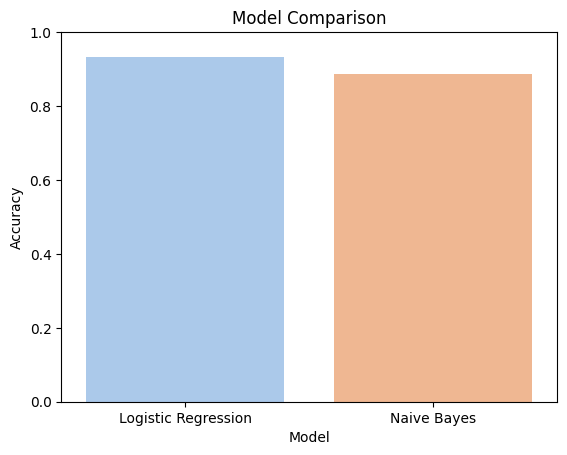

In [102]:
# Comparison  
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [lr_acc, nb_acc]
})

print("\n===== Model Comparison =====")
print(results)

sns.barplot(x="Model", y="Accuracy", data=results,palette= 'pastel')
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.show()

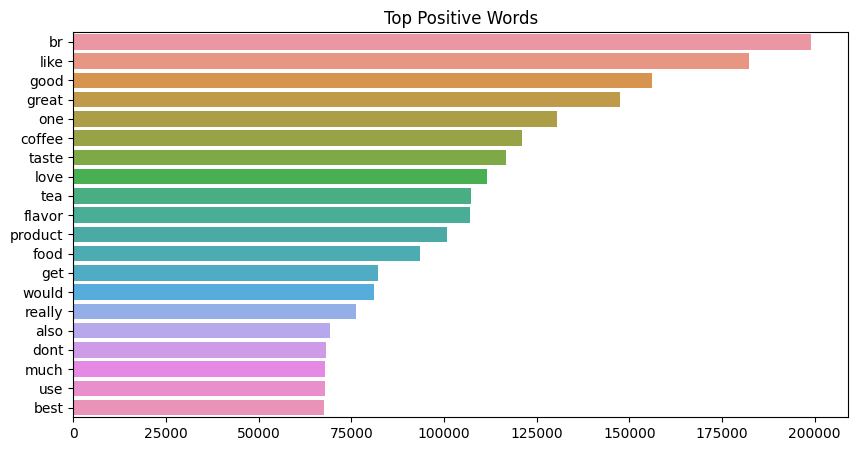

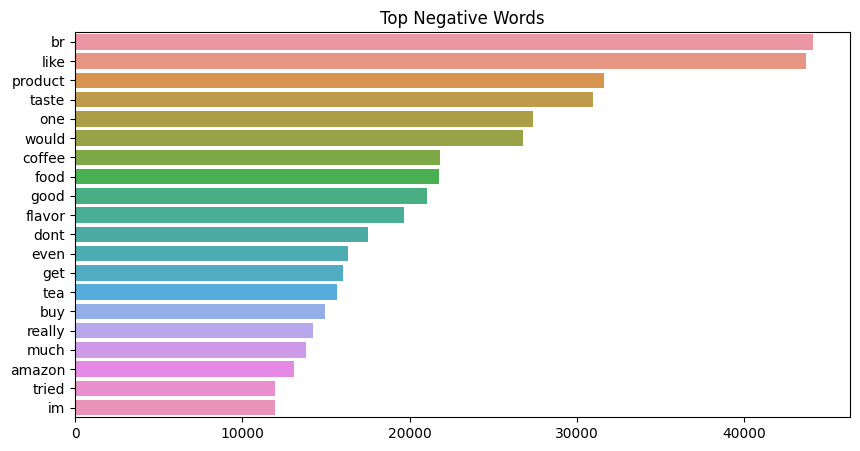

In [125]:
# Positive words
pos_text = " ".join(df[df["Sentiment"] == 1]["clean_text"])
pos_words = pos_text.split()
pos_freq = pd.Series(pos_words).value_counts().head(20)

plt.figure(figsize=(10,5))
sns.barplot(x=pos_freq.values, y=pos_freq.index)
plt.title("Top Positive Words")
plt.show()

# Negative words
neg_text = " ".join(df[df["Sentiment"] == 0]["clean_text"])
neg_words = neg_text.split()
neg_freq = pd.Series(neg_words).value_counts().head(20)

plt.figure(figsize=(10,5))
sns.barplot(x=neg_freq.values, y=neg_freq.index)
plt.title("Top Negative Words")
plt.show()